# Fraud Detection Model

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, f1_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')

## 1. LOAD AND PREPARE DATA

Loads creditcard.csv into a DataFrame and immediately shows its shape and fraud percentage, giving a quick health check on dataset size and class imbalance.

In [8]:
print("🔄 Loading data...")
file_path = Path("../data/data_raw.csv")
df = pd.read_csv(file_path)
print(f"✅ Dataset shape: {df.shape}")
print(f"📊 Fraud ratio: {df['Class'].sum()/len(df)*100:.2f}%")

🔄 Loading data...
✅ Dataset shape: (284807, 31)
📊 Fraud ratio: 0.17%


## 2. PREPROCESSING

Splits features from the Class label, scales the un‑anonymised “Time” and “Amount” columns so they sit on the same numerical footing as the PCA‑generated V1…V28 variables, creates three interaction terms (Amount_Time, V1_V2, V3_V4) to capture non‑linear relationships the PCA step might miss, and finally performs a stratified 60‑20‑20 split to preserve the fraud ratio across train, validation and test sets.

In [9]:
print("\n🔧 Preprocessing data (safe)...")

# Separate features and target
X_full = df.drop('Class', axis=1)
y_full = df['Class']

# --- 1️⃣ Split: Train (60%), Validation (20%), Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# --- 2️⃣ Fit scaler only on training set
scaler = StandardScaler().fit(X_train[['Amount', 'Time']])

# --- 3️⃣ Apply scaling to each split
for frame in (X_train, X_val, X_test):
    frame[['Amount', 'Time']] = scaler.transform(frame[['Amount', 'Time']])

# --- 4️⃣ Add interaction features (consistent across splits)
for frame in (X_train, X_val, X_test):
    frame['Amount_Time'] = frame['Amount'] * frame['Time']
    frame['V1_V2'] = frame['V1'] * frame['V2']
    frame['V3_V4'] = frame['V3'] * frame['V4']

print(f"✅ Train set: {X_train.shape}")
print(f"✅ Validation set: {X_val.shape}")
print(f"✅ Test set: {X_test.shape}")


🔧 Preprocessing data (safe)...
✅ Train set: (170883, 33)
✅ Validation set: (56962, 33)
✅ Test set: (56962, 33)


## 3. BALANCE TRAINING DATA WITH SMOTE

Applies SMOTE to the training partition only, creating synthetic fraud samples until the classes are balanced and preventing synthetic data from leaking into validation or test metrics.

In [10]:
print("\n⚖️ Balancing training data with SMOTE...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"✅ Balanced training samples: {len(X_train_balanced):,}")


⚖️ Balancing training data with SMOTE...
✅ Balanced training samples: 341,176


## 4. TRAIN RANDOM FOREST MODEL

Fits a 100‑tree Random Forest with depth limits that curb over‑fitting, using the SMOTE‑balanced training data so each tree learns from an equal mix of fraud and non‑fraud transactions.

In [11]:
print("\n🎯 Training Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_balanced, y_train_balanced)
print("✅ Model training complete!")


🎯 Training Random Forest model...
✅ Model training complete!


## 5. FIND OPTIMAL THRESHOLD

Generates fraud probabilities on the validation set, sweeps possible decision thresholds and selects the one that maximises F1‑score, striking the best precision‑recall compromise for this imbalanced problem.

In [12]:
print("\n🔍 Finding optimal threshold using validation set...")

# Get probabilities on validation set
y_val_proba = rf_model.predict_proba(X_val)[:, 1]

# Calculate metrics for different thresholds
thresholds = np.arange(0.1, 0.9, 0.01)
metrics = {
    'threshold': thresholds,
    'f1_score': [],
    'precision': [],
    'recall': []
}

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics['f1_score'].append(f1)
    metrics['precision'].append(precision)
    metrics['recall'].append(recall)

# Convert to DataFrame for easier handling
metrics_df = pd.DataFrame(metrics)

# Find optimal threshold (maximize F1-score)
optimal_idx = np.argmax(metrics_df['f1_score'])
optimal_threshold = metrics_df.iloc[optimal_idx]['threshold']
optimal_f1 = metrics_df.iloc[optimal_idx]['f1_score']

print(f"\n🎯 Optimal threshold: {optimal_threshold:.3f}")
print(f"📊 Validation F1-score at optimal threshold: {optimal_f1:.4f}")


🔍 Finding optimal threshold using validation set...

🎯 Optimal threshold: 0.640
📊 Validation F1-score at optimal threshold: 0.7853


## 6. VISUALIZE THRESHOLD OPTIMIZATION

Plots how precision, recall and F1 change with the threshold and draws a precision‑recall curve, visually confirming the cut‑off chosen in the previous step.

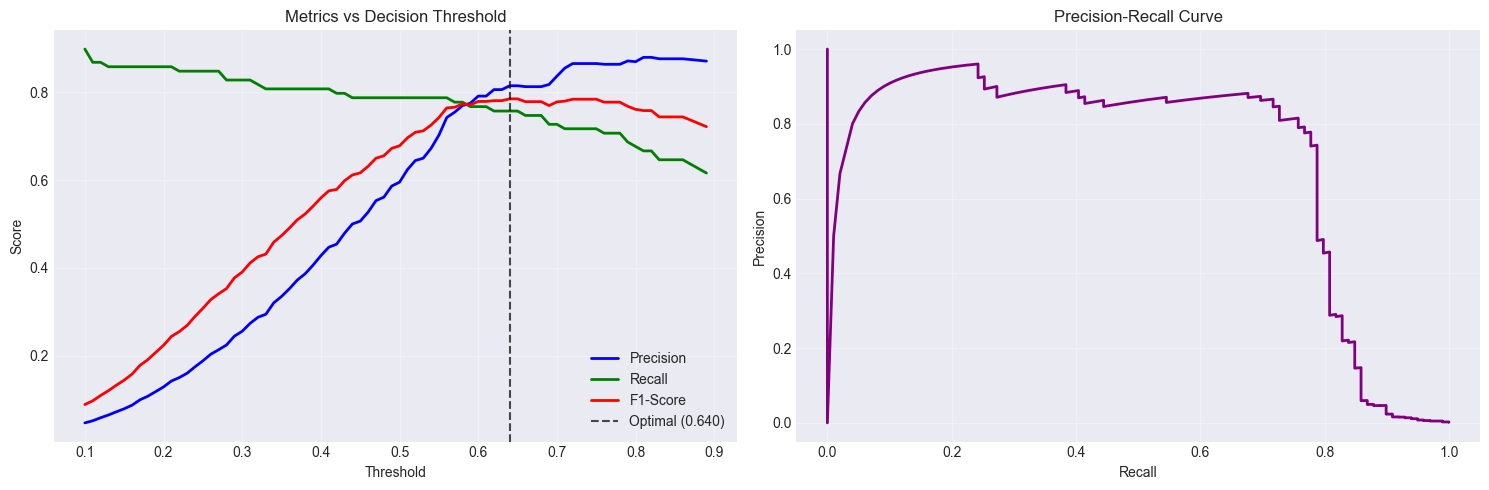

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Metrics vs Threshold
ax1.plot(metrics_df['threshold'], metrics_df['precision'], label='Precision', color='blue', linewidth=2)
ax1.plot(metrics_df['threshold'], metrics_df['recall'], label='Recall', color='green', linewidth=2)
ax1.plot(metrics_df['threshold'], metrics_df['f1_score'], label='F1-Score', color='red', linewidth=2)
ax1.axvline(optimal_threshold, color='black', linestyle='--', alpha=0.7, label=f'Optimal ({optimal_threshold:.3f})')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Metrics vs Decision Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curve
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_val, y_val_proba)
ax2.plot(recall_curve, precision_curve, color='purple', linewidth=2)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. EVALUATE ON TEST SET WITH OPTIMAL THRESHOLD

Applies both the default 0.5 threshold and the tuned threshold to the held‑out test data, then reports confusion matrix, precision, recall, F1 and ROC‑AUC so it is possible to quantify the real‑world benefit of threshold tuning.

In [14]:
print("\n📈 Evaluating on test set with optimal threshold...")

# Get test probabilities
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

# Default predictions (threshold = 0.5)
y_pred_default = rf_model.predict(X_test)

# Optimized predictions
y_pred_optimized = (y_test_proba >= optimal_threshold).astype(int)

# Calculate metrics for both
def calculate_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc   = roc_auc_score(y_true, y_proba)
    accuracy  = (tp + tn) / (tp + tn + fp + fn)
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'accuracy': accuracy,
        'confusion_matrix': cm
    }

# Compare default vs optimized
default_metrics = calculate_metrics(y_test, y_pred_default, y_test_proba)
optimized_metrics = calculate_metrics(y_test, y_pred_optimized, y_test_proba)

print("\n📊 PERFORMANCE COMPARISON:")
print("-" * 60)
print(f"{'Metric':<15} {'Default (0.5)':<20} {'Optimized':<20}")
print("-" * 60)
print(f"{'Threshold':<15} {0.5:<20.3f} {optimal_threshold:<20.3f}")
print(f"{'ROC-AUC':<15} {default_metrics['roc_auc']:<20.4f} {optimized_metrics['roc_auc']:<20.4f}")
print(f"{'Accuracy':<15} {default_metrics['accuracy']:<20.2%} {optimized_metrics['accuracy']:<20.2%}")
print(f"{'Precision':<15} {default_metrics['precision']:<20.2%} {optimized_metrics['precision']:<20.2%}")
print(f"{'Recall':<15} {default_metrics['recall']:<20.2%} {optimized_metrics['recall']:<20.2%}")
print(f"{'F1-Score':<15} {default_metrics['f1_score']:<20.2%} {optimized_metrics['f1_score']:<20.2%}")


📈 Evaluating on test set with optimal threshold...

📊 PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric          Default (0.5)        Optimized           
------------------------------------------------------------
Threshold       0.500                0.640               
ROC-AUC         0.9820               0.9820              
Accuracy        99.87%               99.93%              
Precision       58.39%               76.92%              
Recall          81.63%               81.63%              
F1-Score        68.09%               79.21%              


## 8. VISUALIZE FINAL RESULTS

Displays a heat‑mapped confusion matrix, ROC curve with AUC, and the top‑ten feature importances, providing an at‑a‑glance view of model errors, overall ranking ability and the variables driving predictions.

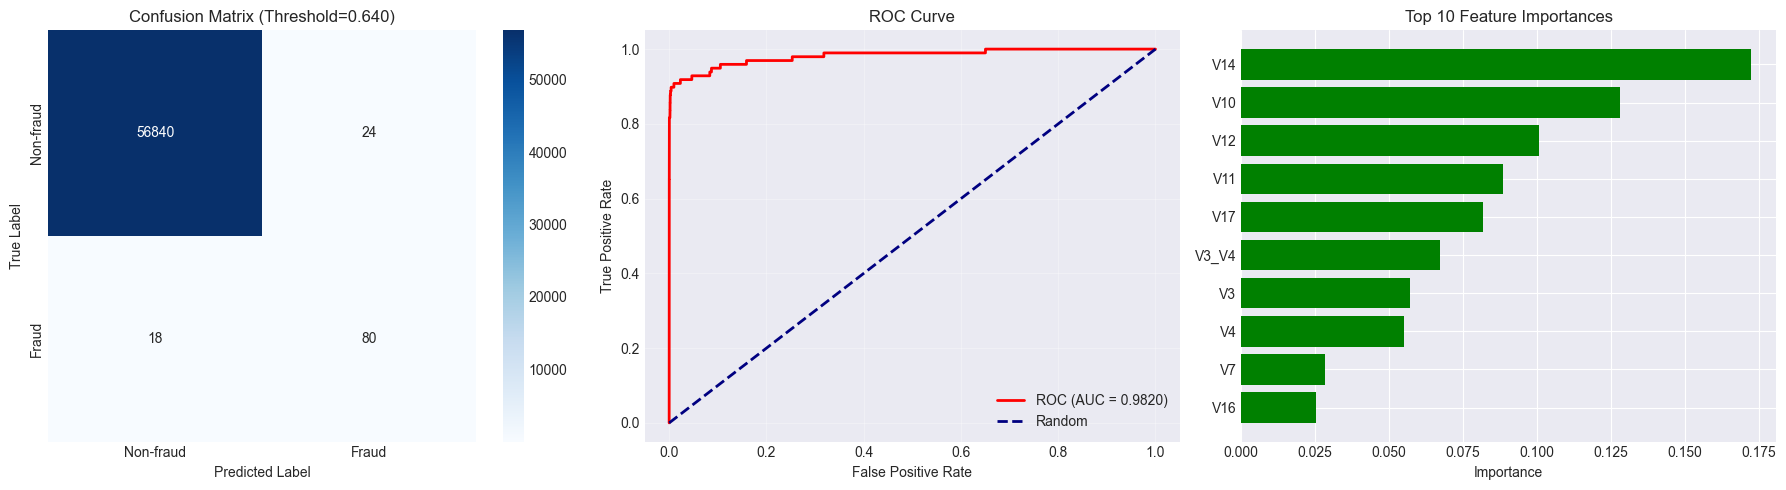

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix - Optimized
sns.heatmap(optimized_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-fraud', 'Fraud'], yticklabels=['Non-fraud', 'Fraud'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Threshold={optimal_threshold:.3f})')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, color='red', lw=2, label=f'ROC (AUC = {optimized_metrics["roc_auc"]:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Feature Importance (Top 10)
feature_importance = pd.DataFrame({
    'feature': X_test.columns,  # Changed from X.columns to X_test.columns
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

axes[2].barh(feature_importance['feature'], feature_importance['importance'], color='green')
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 10 Feature Importances')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. DETAILED CLASSIFICATION REPORT

Prints scikit‑learn’s full classification report plus a short summary of the key metrics and chosen threshold

In [16]:
print("\n📋 DETAILED CLASSIFICATION REPORT:")
print(classification_report(
    y_test, y_pred_optimized, 
    target_names=['Non-fraud', 'Fraud'], 
    digits=4
))

print(f"\n🎯 FINAL MODEL SUMMARY:")
print(f"- Optimal Threshold: {optimal_threshold:.3f}")
print(f"- ROC-AUC Score: {optimized_metrics['roc_auc']:.4f}")
print(f"- Accuracy: {optimized_metrics['accuracy']:.2%}")
print(f"- Precision: {optimized_metrics['precision']:.2%}")
print(f"- Recall: {optimized_metrics['recall']:.2%}")
print(f"- F1-Score: {optimized_metrics['f1_score']:.2%}")


📋 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   Non-fraud     0.9997    0.9996    0.9996     56864
       Fraud     0.7692    0.8163    0.7921        98

    accuracy                         0.9993     56962
   macro avg     0.8845    0.9080    0.8959     56962
weighted avg     0.9993    0.9993    0.9993     56962


🎯 FINAL MODEL SUMMARY:
- Optimal Threshold: 0.640
- ROC-AUC Score: 0.9820
- Accuracy: 99.93%
- Precision: 76.92%
- Recall: 81.63%
- F1-Score: 79.21%


## 10. Downloading model

In [17]:
import joblib
from pathlib import Path

# --- Create a dictionary containing all components for prediction ---
model_payload = {
    'model': rf_model,
    'scaler': scaler,
    'threshold': optimal_threshold
}

# --- Define the file path for the saved model ---
model_path = Path("fraud_detection_model.pkl")

# --- Save the payload to a .pkl file ---
joblib.dump(model_payload, model_path)

print(f"✅ Model, scaler, and threshold successfully saved to: {model_path}")

✅ Model, scaler, and threshold successfully saved to: fraud_detection_model.pkl
